=== Inhibiteur A ===
  No inhibitor : Vmax = 14.978 mM/min,  Km = 0.399 mM
  Inhibitor A ([A]=CA) : Vmax = 14.964 mM/min,  Km = 0.798 mM

=== Inhibiteur B ===
  No inhibitor : Vmax = 14.978 mM/min,  Km = 0.399 mM
  Inhibitor B ([B]=CB) : Vmax = 6.025 mM/min,  Km = 0.403 mM


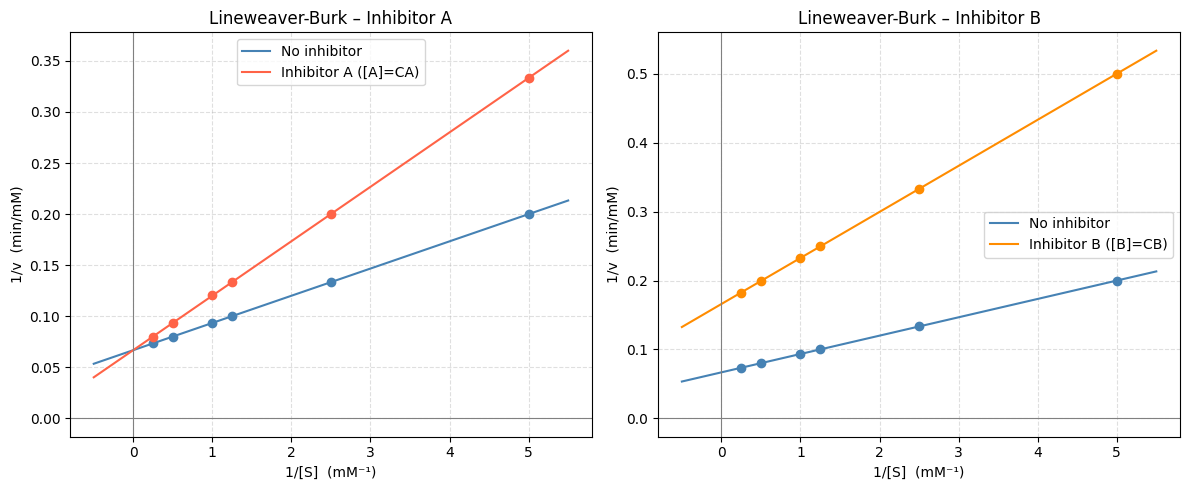

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Données
S = np.array([0.2, 0.4, 0.8, 1.0, 2.0, 4.0])  # mM
v_no_inh = np.array([5.0, 7.5, 10.0, 10.7, 12.5, 13.6])   # mM/min
v_inh_A  = np.array([3.0, 5.0, 7.5,  8.3, 10.7, 12.5])
v_inh_B  = np.array([2.0, 3.0, 4.0,  4.3,  5.0,  5.5])

# Transformation Lineweaver-Burk : 1/v vs 1/[S]
inv_S      = 1 / S
inv_v_no   = 1 / v_no_inh
inv_v_A    = 1 / v_inh_A
inv_v_B    = 1 / v_inh_B

# Régression linéaire pour chaque condition
def linreg(x, y):
    coeffs = np.polyfit(x, y, 1)  # [slope, intercept]
    return coeffs

def plot_LB(ax, inv_S, inv_v_no, inv_v_inh, inh_label, color_inh):
    """Trace le graphe Lineweaver-Burk pour une paire no inhibitor / inhibitor."""
    c_no  = linreg(inv_S, inv_v_no)
    c_inh = linreg(inv_S, inv_v_inh)

    x_fit = np.linspace(-0.5, max(inv_S) * 1.1, 200)

    ax.scatter(inv_S, inv_v_no,  color='steelblue', zorder=5)
    ax.scatter(inv_S, inv_v_inh, color=color_inh,   zorder=5)

    ax.plot(x_fit, np.polyval(c_no,  x_fit), color='steelblue', label='No inhibitor')
    ax.plot(x_fit, np.polyval(c_inh, x_fit), color=color_inh,   label=inh_label)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)

    ax.set_xlabel('1/[S]  (mM⁻¹)')
    ax.set_ylabel('1/v  (min/mM)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

    # Annotations des paramètres cinétiques
    Vmax_no  = 1 / c_no[1]
    Km_no    = c_no[0] * Vmax_no
    Vmax_inh = 1 / c_inh[1]
    Km_inh   = c_inh[0] * Vmax_inh

    print(f"  No inhibitor : Vmax = {Vmax_no:.3f} mM/min,  Km = {Km_no:.3f} mM")
    print(f"  {inh_label:12s} : Vmax = {Vmax_inh:.3f} mM/min,  Km = {Km_inh:.3f} mM")

    return c_no, c_inh

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

print("=== Inhibiteur A ===")
plot_LB(ax1, inv_S, inv_v_no, inv_v_A, 'Inhibitor A ([A]=CA)', 'tomato')
ax1.set_title('Lineweaver-Burk – Inhibitor A')

print("\n=== Inhibiteur B ===")
plot_LB(ax2, inv_S, inv_v_no, inv_v_B, 'Inhibitor B ([B]=CB)', 'darkorange')
ax2.set_title('Lineweaver-Burk – Inhibitor B')

plt.tight_layout()
plt.savefig('lineweaver_burk_1a.png', dpi=150)
plt.show()